<a href="https://colab.research.google.com/github/azeltkr/breast-cancer-cbis-ddsm/blob/main/CM3070_prototype_cbis_ddsm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CM3070 Feature Prototype (Kaggle route)
## Deep Learning for Breast Cancer Detection (CBIS-DDSM)

This notebook loads CBIS-DDSM from Kaggle (JPEG images + CSV labels), bypassing TensorFlow Datasets. It implements **Steps 1 to 3** of the Chollet pipeline (framing, data preparation, baseline CNN) plus a short **VGG16 transfer-learning** taste, and evaluates with **AUC-ROC, sensitivity, specificity, and a confusion matrix**.



In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Download the dataset
!pip install -q kaggle
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset
!unzip -q -o cbis-ddsm-breast-cancer-image-dataset.zip -d /content/cbis
print('Done. Top-level contents:')
!ls /content/cbis

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:46<00:00, 113MB/s]

Done. Top-level contents:
csv  jpeg


In [4]:
!ls /content/cbis

csv  jpeg


## 1. Inspect the CSV label files

This dataset ships with calc and mass case description CSVs. We inspect them so the label handling is transparent.

In [9]:
import pandas as pd, glob

csvs = glob.glob('/content/cbis/csv/*.csv')
print('CSV files found:')
for c in csvs:
    print(' ', c)

# Peek at one to see columns
sample = pd.read_csv(csvs[0])
print('\nColumns:', list(sample.columns))
sample.head()

CSV files found:
  /content/cbis/csv/mass_case_description_test_set.csv
  /content/cbis/csv/meta.csv
  /content/cbis/csv/dicom_info.csv
  /content/cbis/csv/calc_case_description_test_set.csv
  /content/cbis/csv/mass_case_description_train_set.csv
  /content/cbis/csv/calc_case_description_train_set.csv

Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....


In [10]:
# Look at the directory layout for the images (jpeg folder).
!ls /content/cbis | head
print('---')
!ls /content/cbis/jpeg 2>/dev/null | head || echo 'no jpeg/ folder; checking alternatives'
print('--- dicom_info or meta ---')
!ls /content/cbis/csv

csv
jpeg
---
1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132
1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547
1.3.6.1.4.1.9590.100.1.2.100522099512256189513864912954167862869
1.3.6.1.4.1.9590.100.1.2.100522676511025180541602449080267145647
1.3.6.1.4.1.9590.100.1.2.10055294210766234140934516480682841962
1.3.6.1.4.1.9590.100.1.2.100579676611077714807988832023693299884
1.3.6.1.4.1.9590.100.1.2.100631678311747240317898717702514834166
1.3.6.1.4.1.9590.100.1.2.100632214012866120117337678502539182046
1.3.6.1.4.1.9590.100.1.2.100682860911308271813943300011840547108
1.3.6.1.4.1.9590.100.1.2.100764250811134786606184452222065316702
--- dicom_info or meta ---
calc_case_description_test_set.csv   mass_case_description_test_set.csv
calc_case_description_train_set.csv  mass_case_description_train_set.csv
dicom_info.csv			     meta.csv


## 2. Build a labelled dataframe (image path -> binary label)

We combine the calc and mass training/test description CSVs, map `pathology` to a binary label (`MALIGNANT` -> 1, otherwise 0), and resolve the image paths. The dataset stores images under `jpeg/<hash>/` and maps them via `dicom_info.csv`.


In [11]:
import pandas as pd, os, glob

csv_dir = '/content/cbis/csv'

# 1. Load all four description CSVs and attach the binary label
frames = []
for f in ['calc_case_description_train_set.csv', 'calc_case_description_test_set.csv',
          'mass_case_description_train_set.csv', 'mass_case_description_test_set.csv']:
    p = os.path.join(csv_dir, f)
    if os.path.exists(p):
        df = pd.read_csv(p)
        frames.append(df)
desc = pd.concat(frames, ignore_index=True)
desc['label'] = (desc['pathology'].str.upper() == 'MALIGNANT').astype(int)
print("Description rows:", len(desc))
print("Label counts:\n", desc['label'].value_counts())

# 2. Use dicom_info to map full-mammogram images, keyed by the DDSM-style name
di = pd.read_csv(csv_dir + '/dicom_info.csv')
full = di[di['SeriesDescription'] == 'full mammogram images'].copy()

# Resolve the real jpg path
img_root = '/content/cbis'
full['real_path'] = full['image_path'].str.replace('CBIS-DDSM', img_root, regex=False)

# The PatientID in dicom_info (e.g. Mass-Training_P_01265_RIGHT_MLO) encodes
# patient + side + view. Build the same key from the description CSV and join on it.
def make_key(row):
    # e.g. Mass-Training_P_01265_RIGHT_MLO  -> P_01265_RIGHT_MLO
    pid = str(row['patient_id'])
    side = str(row['left or right breast']).upper().strip()
    view = str(row['image view']).upper().strip()
    return f"{pid}_{side}_{view}"

desc['join_key'] = desc.apply(make_key, axis=1)

# Extract the same key from dicom_info PatientID by stripping the prefix and any trailing _n
import re
def extract_key(pid):
    m = re.search(r'(P_\d+_[A-Z]+_[A-Z]+)', str(pid))
    return m.group(1) if m else None
full['join_key'] = full['PatientID'].apply(extract_key)

# 3. Join: each full image gets the label of its matching description row
merged = full.merge(desc[['join_key', 'label']].drop_duplicates('join_key'),
                    on='join_key', how='inner')
merged = merged[merged['real_path'].apply(os.path.exists)]

# pull the patient ID out of the join key (P_00016_LEFT_CC -> P_00016)
merged['patient'] = merged['join_key'].str.extract(r'(P_\d+)')

pairs = list(zip(merged['real_path'], merged['label'], merged['patient']))
print("\nTotal (path, label, patient) triples:", len(pairs))
print("Unique patients:", merged['patient'].nunique())

Description rows: 3568
Label counts:
 label
0    2111
1    1457
Name: count, dtype: int64

Total (path, label, patient) triples: 2857
Unique patients: 1460


> If the path above resolves (`Exists: True`), continue. The next cell joins labels to image paths via the patient/image identifiers and assembles the final training table.

The description CSVs and the image files are linked through `dicom_info.csv`.
We filter to `full mammogram images` rather than the cropped ROI patches,
because the research question concerns whole-image screening: a real screening
model receives an entire mammogram, not a pre-localised region. This is also
the main structural difference from Shen et al. (2019), who trained a patch
classifier on the ROI annotations before converting it to a whole-image model.

## 3. Build tf.data pipelines (resize, normalise, augment, class-weight)

In [12]:
import pandas as pd
csv_dir = '/content/cbis/csv'

desc_sample = pd.read_csv(csv_dir + '/mass_case_description_train_set.csv')
di = pd.read_csv(csv_dir + '/dicom_info.csv')

print("=== DESCRIPTION CSV ===")
print("Columns:", list(desc_sample.columns))
print("patient_id examples:", desc_sample['patient_id'].head(5).tolist() if 'patient_id' in desc_sample.columns else 'NO patient_id COLUMN')

print("\n=== DICOM_INFO ===")
print("Columns:", list(di.columns))
for col in ['PatientID', 'patient_id', 'image_path', 'SeriesDescription']:
    if col in di.columns:
        print(f"{col} examples:", di[col].head(5).tolist())

=== DESCRIPTION CSV ===
Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
patient_id examples: ['P_00001', 'P_00001', 'P_00004', 'P_00004', 'P_00004']

=== DICOM_INFO ===
Columns: ['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestIma

In [13]:
import tensorflow as tf
import numpy as np, os
from sklearn.model_selection import GroupShuffleSplit

SEED = 42; tf.random.set_seed(SEED); np.random.seed(SEED)
IMG_SIZE = 128; BATCH = 32

paths  = np.array([p for p, _, _ in pairs])
labels = np.array([l for _, l, _ in pairs], dtype=np.float32)
groups = np.array([g for _, _, g in pairs])

def is_valid_jpeg(path):
    try:
        with open(path, 'rb') as f:
            return f.read(3) == b'\xff\xd8\xff'
    except Exception:
        return False

print("Checking image validity...")
valid = np.array([is_valid_jpeg(p) for p in paths])
print(f"Valid: {valid.sum()} / {len(paths)}")
paths, labels, groups = paths[valid], labels[valid], groups[valid]

# ---- Three-way patient-level split, class-balanced ----
# StratifiedGroupKFold keeps whole patients together AND balances classes.
# 7 folds: one for test, one for val, the remaining five for train (~72/14/14)
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
folds = list(sgkf.split(paths, labels.astype(int), groups=groups))

test_idx  = folds[0][1]
val_idx   = folds[1][1]
train_idx = np.setdiff1d(np.arange(len(paths)),
                         np.concatenate([test_idx, val_idx]))

p_train, y_train = paths[train_idx], labels[train_idx]
p_val,   y_val   = paths[val_idx],   labels[val_idx]
p_test,  y_test  = paths[test_idx],  labels[test_idx]

print(f"\nTrain: {len(p_train)}   Val: {len(p_val)}   Test: {len(p_test)}")
print("Patient overlap (all must be 0):",
      f"train/val={len(set(groups[train_idx]) & set(groups[val_idx]))}",
      f"train/test={len(set(groups[train_idx]) & set(groups[test_idx]))}",
      f"val/test={len(set(groups[val_idx]) & set(groups[test_idx]))}")
print(f"Malignant rate  train {y_train.mean():.3f} | "
      f"val {y_val.mean():.3f} | test {y_test.mean():.3f}")

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=3, try_recover_truncated=True,
                            acceptable_fraction=0.5)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img / 255.0, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE

ds_train = (tf.data.Dataset.from_tensor_slices((p_train, y_train))
            .map(load_img, num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(len(p_train), seed=SEED)
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH).prefetch(AUTOTUNE))

ds_val = (tf.data.Dataset.from_tensor_slices((p_val, y_val))
          .map(load_img, num_parallel_calls=AUTOTUNE)
          .cache()
          .batch(BATCH).prefetch(AUTOTUNE))

ds_test = (tf.data.Dataset.from_tensor_slices((p_test, y_test))
           .map(load_img, num_parallel_calls=AUTOTUNE)
           .cache()
           .batch(BATCH).prefetch(AUTOTUNE))

pos = int(y_train.sum()); neg = len(y_train) - pos; tot = len(y_train)
class_weight = {0: tot/(2*neg), 1: tot/(2*pos)}
print('Class weights:', class_weight)

Checking image validity...
Valid: 2857 / 2857

Train: 2035   Val: 405   Test: 417
Patient overlap (all must be 0): train/val=0 train/test=0 val/test=0
Malignant rate  train 0.449 | val 0.477 | test 0.420
Class weights: {0: 0.907671721677074, 1: 1.113238512035011}


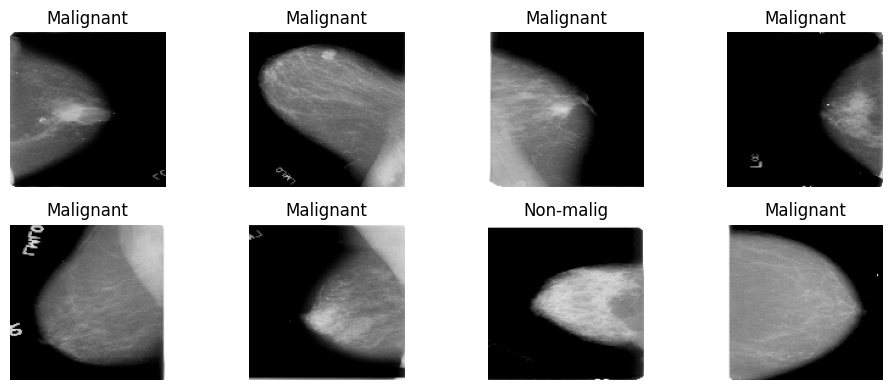

In [14]:
# Sanity-check a batch
import matplotlib.pyplot as plt
for imgs, lbls in ds_train.take(1):
    plt.figure(figsize=(10,4))
    for i in range(8):
        plt.subplot(2,4,i+1); plt.imshow(imgs[i].numpy())
        plt.title('Malignant' if lbls[i]==1 else 'Non-malig'); plt.axis('off')
    plt.tight_layout(); plt.show()

## 4. Baseline small CNN (beat naive AUC = 0.5)

In [15]:
def make_baseline():
    m = tf.keras.Sequential([
        tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.Conv2D(16, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

def stop_report(hist, es, name):
    m = hist.model
    ran  = len(hist.history['val_auc'])
    best = max(hist.history['val_auc'])
    best_ep = hist.history['val_auc'].index(best) + 1
    if es.stopped_epoch:
        print(f"{name}: STOPPED EARLY at epoch {ran} (patience {es.patience} exhausted)")
    else:
        print(f"{name}: ran all {ran} epochs, still improving, raise the ceiling")
    print(f"{name}: best val AUC {best:.4f} at epoch {best_ep}, weights restored there")
    print(f"{name}: trained model = {m.name}, {m.count_params():,} params")

baseline = make_baseline()
es = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                      patience=15, restore_best_weights=True)

hist_base = baseline.fit(ds_train, validation_data=ds_val,
                         epochs=150, class_weight=class_weight,
                         callbacks=[es], verbose=1)
stop_report(hist_base, es, 'Baseline')

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s 600ms/step - auc: 0.5216 - loss: 0.6927 - val_auc: 0.5242 - val_loss: 0.6943
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.5261 - loss: 0.6927 - val_auc: 0.5182 - val_loss: 0.6942
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.5254 - loss: 0.6915 - val_auc: 0.5215 - val_loss: 0.6942
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.5446 - loss: 0.6904 - val_auc: 0.5211 - val_loss: 0.6925
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.5662 - loss: 0.6881 - val_auc: 0.5292 - val_loss: 0.6926
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.5657 - loss: 0.6870 - val_auc: 0.5337 - val_loss: 0.6937
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.5691 - loss: 0.6865 - val_auc: 0.5375 - val_loss: 0.6981
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.5955 - loss: 0.6801 - val_auc: 0.5544 - val_loss: 0.6900
Epoch 9/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - 

## 5. VGG16 transfer-learning taste (frozen base)

In [17]:
base = tf.keras.applications.VGG16(include_top=False, weights='imagenet',
                                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False
vgg = tf.keras.Sequential([
    tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
vgg.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
            loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
es_v = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                        patience=15, restore_best_weights=True)
hist_vgg = vgg.fit(ds_train, validation_data=ds_val,
                   epochs=150, class_weight=class_weight,
                   callbacks=[es_v], verbose=1)

stop_report(hist_vgg, es_v, 'VGG16')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - auc: 0.4733 - loss: 0.7835 - val_auc: 0.4978 - val_loss: 0.6933
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - auc: 0.5103 - loss: 0.7143 - val_auc: 0.5579 - val_loss: 0.6883
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - auc: 0.5277 - loss: 0.7036 - val_auc: 0.6025 - val_loss: 0.6843
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - auc: 0.5415 - loss: 0.6979 - val_auc: 0.6209 - val_loss: 0.6818
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - auc: 0.5335 - loss: 0.6995 - val_auc: 0.6317 - val_loss: 0.6793
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - auc: 0.5581 - loss: 0.6896 - val_auc: 0.6377 - val_loss: 0.6766
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - auc: 0.5872 - loss: 0.6821 - val_auc: 0.6420 - val_loss: 0.6748
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - auc: 0.5967 - loss: 0.6801 - val_auc: 0.6479 - val_loss: 0.6727
Epo

## 6. Evaluation: AUC, sensitivity, specificity, confusion matrix, ROC


=== Baseline CNN ===
AUC-ROC:     0.717
Sensitivity: 0.663
Specificity: 0.591
Confusion [tn fp / fn tp]: [143 99 / 59 116]
Missed cancers (FN): 59 of 175 malignant cases

=== VGG16 transfer ===
AUC-ROC:     0.656
Sensitivity: 0.686
Specificity: 0.595
Confusion [tn fp / fn tp]: [144 98 / 55 120]
Missed cancers (FN): 55 of 175 malignant cases


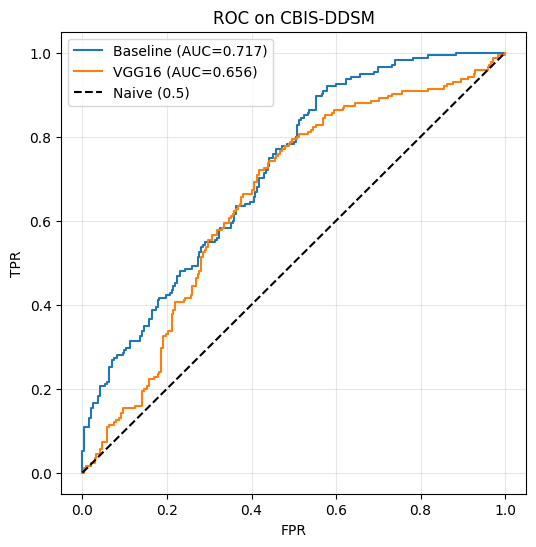

In [27]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

def evaluate(model, name):
    y_prob = model.predict(ds_test, verbose=0).ravel()
    auc = roc_auc_score(y_test, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp/(tp+fn) if (tp+fn) else 0
    spec = tn/(tn+fp) if (tn+fp) else 0
    print(f'\n=== {name} ===')
    print(f'AUC-ROC:     {auc:.3f}')
    print(f'Sensitivity: {sens:.3f}')
    print(f'Specificity: {spec:.3f}')
    print(f'Confusion [tn fp / fn tp]: [{tn} {fp} / {fn} {tp}]')
    print(f'Missed cancers (FN): {fn} of {tp+fn} malignant cases')
    return auc, y_prob

auc_b, prob_b = evaluate(baseline, 'Baseline CNN')
auc_v, prob_v = evaluate(vgg, 'VGG16 transfer')

plt.figure(figsize=(6,6))
for name, prob, auc in [('Baseline', prob_b, auc_b), ('VGG16', prob_v, auc_v)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',label='Naive (0.5)')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('ROC on CBIS-DDSM'); plt.grid(alpha=0.3); plt.savefig('/content/drive/MyDrive/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

**Side-by-side Confusion Matrices**

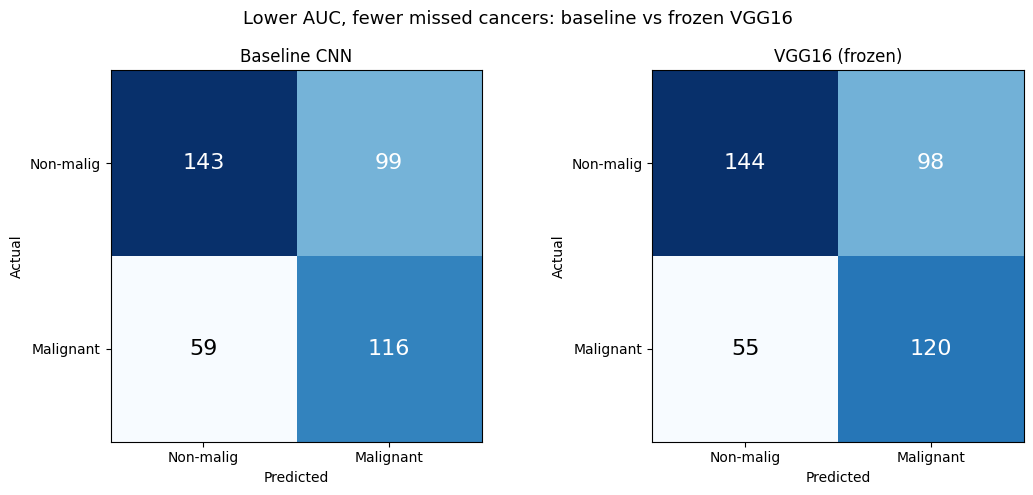

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

def plot_cm(ax, cm, title):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Non-malig','Malignant'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Non-malig','Malignant'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    for i,j in itertools.product(range(2), range(2)):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=16,
                color='white' if cm[i,j] > cm.max()/2 else 'black')

prob_b = baseline.predict(ds_test, verbose=0).ravel()
prob_v = vgg.predict(ds_test, verbose=0).ravel()
yt = y_test[:len(prob_b)]
cm_b = confusion_matrix(yt, (prob_b>=0.5).astype(int))
cm_v = confusion_matrix(yt, (prob_v>=0.5).astype(int))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))
plot_cm(ax1, cm_b, 'Baseline CNN')
plot_cm(ax2, cm_v, 'VGG16 (frozen)')
plt.suptitle('Lower AUC, fewer missed cancers: baseline vs frozen VGG16', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Example Predictions on real mammograms**

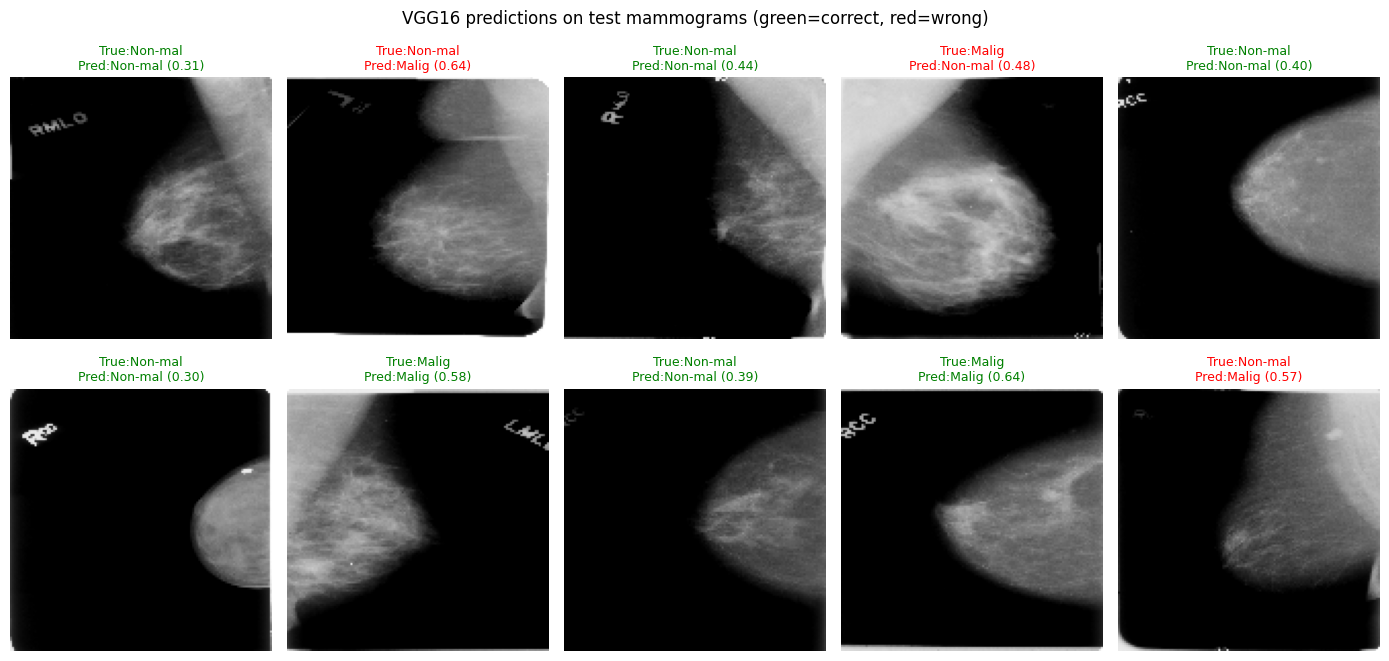

In [21]:
# Show a grid of test images with predicted vs true labels
batch_imgs, batch_lbls = next(iter(ds_test))
preds = vgg.predict(batch_imgs, verbose=0).ravel()

plt.figure(figsize=(14, 7))
for i in range(min(10, len(batch_imgs))):
    plt.subplot(2, 5, i+1)
    plt.imshow(batch_imgs[i].numpy())
    true = 'Malig' if batch_lbls[i]==1 else 'Non-mal'
    pred = 'Malig' if preds[i]>=0.5 else 'Non-mal'
    correct = (batch_lbls[i]==1) == (preds[i]>=0.5)
    plt.title(f'True:{true}\nPred:{pred} ({preds[i]:.2f})',
              color='green' if correct else 'red', fontsize=9)
    plt.axis('off')
plt.suptitle('VGG16 predictions on test mammograms (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/example_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

**Training History, showing learning curves**

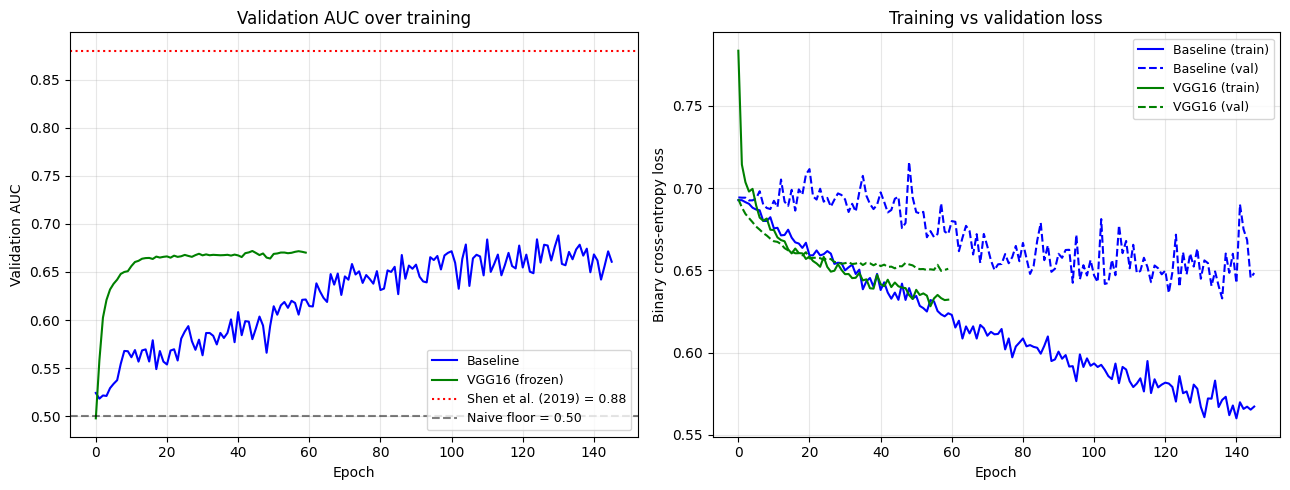

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: validation AUC ---
ax1.plot(hist_base.history['val_auc'], 'b-', lw=1.5, label='Baseline')
ax1.plot(hist_vgg.history['val_auc'],  'g-', lw=1.5, label='VGG16 (frozen)')
ax1.axhline(0.88, color='r', ls=':',  label='Shen et al. (2019) = 0.88')
ax1.axhline(0.50, color='k', ls='--', alpha=0.5, label='Naive floor = 0.50')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation AUC')
ax1.set_title('Validation AUC over training')
ax1.legend(loc='lower right', fontsize=9); ax1.grid(alpha=0.3)

# --- Right: train vs validation loss (solid = train, dashed = validation) ---
ax2.plot(hist_base.history['loss'],     'b-',  lw=1.5, label='Baseline (train)')
ax2.plot(hist_base.history['val_loss'], 'b--', lw=1.5, label='Baseline (val)')
ax2.plot(hist_vgg.history['loss'],      'g-',  lw=1.5, label='VGG16 (train)')
ax2.plot(hist_vgg.history['val_loss'],  'g--', lw=1.5, label='VGG16 (val)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Binary cross-entropy loss')
ax2.set_title('Training vs validation loss')
ax2.legend(loc='upper right', fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

**Protoype Summary**

In [23]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

BENCHMARK = 0.88  # Shen et al. (2019), CBIS-DDSM single model

def summary(prob, name):
    pred = (prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
    auc = roc_auc_score(yt, prob)
    gap = auc - BENCHMARK
    print(f"{name:18} | AUC {auc:.3f} | "
          f"Sens {tp/(tp+fn):.3f} | Spec {tn/(tn+fp):.3f} | "
          f"Missed cancers (FN): {fn:3d} | vs benchmark: {gap:+.3f}")

print("=" * 92)
print(f"{'Model':18} | {'AUC':9} | {'Sensitivity':11} | {'Specificity':11} | Missed | Gap to 0.88")
print("-" * 92)
summary(prob_b, "Baseline CNN")
summary(prob_v, "VGG16 (frozen)")
print("-" * 92)
print(f"{'Benchmark':18} | AUC 0.880 | Shen et al. (2019), CBIS-DDSM single model")
print("=" * 92)

Model              | AUC       | Sensitivity | Specificity | Missed | Gap to 0.88
--------------------------------------------------------------------------------------------
Baseline CNN       | AUC 0.717 | Sens 0.663 | Spec 0.591 | Missed cancers (FN):  59 | vs benchmark: -0.163
VGG16 (frozen)     | AUC 0.656 | Sens 0.686 | Spec 0.595 | Missed cancers (FN):  55 | vs benchmark: -0.224
--------------------------------------------------------------------------------------------
Benchmark          | AUC 0.880 | Shen et al. (2019), CBIS-DDSM single model


## 7. Fine tuning VGG16 (128x128)

The frozen experiment showed VGG16 hitting a ceiling at around epoch 15 and
then staying flat for the remaining 45 epochs. Because only the classifier
head was trainable, the model had extracted everything it could from features
that were learned on ImageNet photographs, and no amount of extra training
could move it further.

This section unfreezes the top convolutional block so those features can
adapt to greyscale mammograms. This completes stage 5 of Chollet's workflow
and tests the claim by Tajbakhsh et al. (2016) that fine tuning, rather than
feature freezing, is what makes transfer learning effective in medical imaging.

Resolution is held constant at 128x128 so that any change can be attributed
to fine tuning alone. Resolution is varied separately in section 6.

In [34]:
!ls -lh /content/drive/MyDrive/*.keras

-rw------- 1 root root 371K Aug  8 05:54 /content/drive/MyDrive/baseline_128.keras
-rw------- 1 root root  57M Aug  8 05:54 /content/drive/MyDrive/vgg16_frozen_128.keras


In [35]:
# Load a fresh copy of the frozen model so the original `vgg` stays intact
vgg_ft = tf.keras.models.load_model('/content/drive/MyDrive/vgg16_frozen_128.keras')
base_ft = vgg_ft.get_layer('vgg16')

# Unfreeze block5 only; earlier blocks hold generic edge and texture
# detectors that transfer well and are left alone
base_ft.trainable = True
for layer in base_ft.layers:
    layer.trainable = layer.name.startswith('block5')

# CRITICAL: must recompile for the trainable changes to take effect.
# Learning rate is 1e-5, ten times smaller than the frozen phase, so the
# pretrained weights are nudged rather than overwritten.
vgg_ft.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy',
               metrics=[tf.keras.metrics.AUC(name='auc')])

trainable = sum(tf.keras.backend.count_params(w) for w in vgg_ft.trainable_weights)
frozen    = sum(tf.keras.backend.count_params(w) for w in vgg_ft.non_trainable_weights)
print(f'Trainable params: {trainable:,}')
print(f'Frozen params:    {frozen:,}')

Trainable params: 7,112,321
Frozen params:    7,635,264


Unfreezing block5 raises the trainable parameter count from roughly 33,000
to just over 7 million. The first four blocks stay frozen because early
convolutional layers learn generic edge and texture detectors that transfer
across image domains, while the later blocks encode object level concepts
specific to ImageNet categories.

The learning rate is the most important setting here. At the 1e-4 used for
the frozen phase, the gradients flowing back from the classifier head would
be large enough to destroy the pretrained features before they had a chance
to adapt.

In [36]:
es_ft = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                         patience=15, restore_best_weights=True)

hist_ft = vgg_ft.fit(ds_train, validation_data=ds_val,
                     epochs=150, class_weight=class_weight,
                     callbacks=[es_ft], verbose=1)

stop_report(hist_ft, es_ft, 'VGG16 fine-tuned')
vgg_ft.save('/content/drive/MyDrive/vgg16_finetuned_128.keras')

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - auc: 0.6887 - loss: 0.6355 - val_auc: 0.6770 - val_loss: 0.6541
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - auc: 0.7047 - loss: 0.6238 - val_auc: 0.6840 - val_loss: 0.6477
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - auc: 0.7178 - loss: 0.6129 - val_auc: 0.6839 - val_loss: 0.6447
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - auc: 0.7404 - loss: 0.5983 - val_auc: 0.6891 - val_loss: 0.6423
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - auc: 0.7399 - loss: 0.5951 - val_auc: 0.6876 - val_loss: 0.6497
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - auc: 0.7550 - loss: 0.5857 - val_auc: 0.6974 - val_loss: 0.6395
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - auc: 0.7613 - loss: 0.5812 - val_auc: 0.6911 - val_loss: 0.6413
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - auc: 0.7779 - loss: 0.5655 - val_auc: 0.6925 - val_loss: 0.6516
Epoch 9/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - 

In [37]:
auc_ft, prob_ft = evaluate(vgg_ft, 'VGG16 fine-tuned (128)')

print('\n--- 128x128 comparison (test set) ---')
print(f'Baseline CNN        AUC {auc_b:.3f}')
print(f'VGG16 frozen        AUC {auc_v:.3f}')
print(f'VGG16 fine-tuned    AUC {auc_ft:.3f}   (vs frozen: {auc_ft-auc_v:+.3f})')



=== VGG16 fine-tuned (128) ===
AUC-ROC:     0.716
Sensitivity: 0.869
Specificity: 0.409
Confusion [tn fp / fn tp]: [99 143 / 23 152]
Missed cancers (FN): 23 of 175 malignant cases

--- 128x128 comparison (test set) ---
Baseline CNN        AUC 0.717
VGG16 frozen        AUC 0.656
VGG16 fine-tuned    AUC 0.716   (vs frozen: +0.061)


In [39]:
vgg_ft.save('/content/drive/MyDrive/vgg16_finetuned_128.keras')

In [42]:
import numpy as np
np.save('/content/drive/MyDrive/prob_b_128.npy', prob_b)
np.save('/content/drive/MyDrive/prob_v_128.npy', prob_v)
np.save('/content/drive/MyDrive/prob_ft_128.npy', prob_ft)

### Findings

Fine tuning raised validation AUC from 0.676 (frozen, mean of two runs) to
0.7185, a gain of +0.043. This exceeds the noise floor of 0.039 established
over four repeated baseline runs, making it the first difference in this
project that can be interpreted as a real effect rather than run-to-run
variation.

The learning curves support the explanation offered for the frozen result.
Frozen VGG16 plateaued at roughly 0.67 by epoch 15 and did not improve over
the following 45 epochs, indicating that the limit was the fixed ImageNet
features rather than insufficient training. Once block5 was unfrozen, the
model exceeded that plateau within 20 epochs. This reproduces, on this
project's own data, the argument by Tajbakhsh et al. (2016) that fine tuning
rather than feature freezing is what makes transfer learning effective in
medical imaging.

**The cost is a large increase in overfitting.** The gap between training and
validation AUC widened from 0.011 in the frozen model to 0.127 at the best
epoch and 0.189 by the time training stopped. With 7.1 million trainable
parameters and only 2,035 training images, this was expected, and early
stopping with restored best weights was the mechanism that recovered a usable
model. Fine tuning therefore bought discrimination at the price of
generalisation, and stronger regularisation is the natural next step.

**On the test set the clinical picture diverges sharply from the AUC.** The
baseline and the fine-tuned model score almost identically (0.717 against
0.716), and on that metric alone would be judged equivalent. However, at the
default threshold of 0.5 the fine-tuned model missed 23 of 175 malignant
cases against the baseline's 59, a 61% reduction, at the cost of 44 additional
false positives. This is approximately 1.2 extra recalls per additional cancer
detected, a favourable trade in a screening context where a recall means a
follow-up scan and a missed cancer means delayed diagnosis.

This result directly supports the evaluation strategy set out in Chapter 3.
Had AUC been reported alone, these two models would have been treated as
interchangeable, and the model missing 36 more cancers might have been
selected.

One caveat should be stated. Because the two models have nearly identical AUC,
the difference in sensitivity reflects where the 0.5 threshold happens to fall
on each model's ROC curve rather than a difference in discriminative ability.
A matched-sensitivity comparison is required to separate the two effects, and
this motivates the threshold analysis in section 9.